In [244]:
import seaborn as sns
import matplotlib.pyplot as plt
import shap
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from xgboost import XGBClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_score, recall_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
from sklearn.inspection import permutation_importance




In [245]:
df_org_XGB = pd.read_csv('Data/Bank Customer Churn Prediction.csv')
df_org_XGB = df_org_XGB.drop('customer_id', axis=1)

In [246]:
y = df_org_XGB['churn']
X = df_org_XGB.drop('churn', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


def feature_in_XGB(df):
    #    df["balance_salary_ratio"] = df["balance"] / (df["estimated_salary"] + 1)
    #   df['tenure>2']=(df['tenure']>=2).astype(int)
    #    df["age_tenure_ratio"] = df["age"] / (df["tenure"] + 1)
    #    df["age_bin"] = pd.cut(df["age"], bins=[18,30,40,50,60,100], labels=False)
    #    df["credit_bin"] = pd.cut(df["credit_score"], bins=5, labels=False)
    #     col_to_drop=['tenure','estimated_salary','credit_score',]
    #   df['credit']=df['credit_score']*df['credit_card']
    #   df["salary_credit_ratio"] = df["estimated_salary"] / (df["credit_score"] + 1)
    #     df["zero_balance"] = (df["balance"] == 0).astype(int)
    #
    #
    #     df["products_1"] = (df["products_number"] == 1).astype(int)
    #     df["products_2"] = (df["products_number"] == 2).astype(int)
    #     df["products_3plus"] = (df["products_number"] >= 3).astype(int)

    col_to_drop = ['credit_card', 'estimated_salary']
    df = df.drop(col_to_drop, axis=1)
    return df


X_train = feature_in_XGB(X_train)
X_test = feature_in_XGB(X_test)
num_X_lr = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_X_lr = X_train.select_dtypes(include=['object', 'string']).columns

num_piline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])
cat_piline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
prepecesing_XGB = ColumnTransformer([
    ('num_piline', num_piline, num_X_lr),
    ('cat_piline', cat_piline, cat_X_lr),
])
model_XGB = Pipeline([('preporc', prepecesing_XGB),
                      ('m_XGB', XGBClassifier())
                      ])



In [247]:
for test in ["precision", "recall", "roc_auc"]:
    punkty_model_XGB = cross_val_score(estimator=model_XGB, X=X_train, y=y_train, cv=5, scoring=test)
    print(test, ": ", punkty_model_XGB.mean().round(4))

precision :  0.6903
recall :  0.4994
roc_auc :  0.8454


## startowe:
precision :  0.6934
recall :  0.4871
roc_auc :  0.8451

In [248]:
from sklearn.inspection import permutation_importance

model_XGB.fit(X_train, y_train)

for sco in ["roc_auc"]:
    f_imp = permutation_importance(
        estimator=model_XGB,
        X=X_test,
        y=y_test,
        n_jobs=-1,
        random_state=42,
        scoring=sco,
        n_repeats=10
    )

    df_f_imp = pd.DataFrame({
        'feature': X_test.columns,
        'importance': f_imp.importances_mean
    }).sort_values(by='importance', ascending=False)

    print(sco, ":\n", df_f_imp)

roc_auc :
            feature  importance
6  products_number    0.120976
3              age    0.115720
5          balance    0.054845
7    active_member    0.032729
1          country    0.029838
2           gender    0.008773
0     credit_score    0.002064
4           tenure    0.001080


In [249]:
X_test_transformed = model_XGB.named_steps['preporc'].transform(X_test)
XGB_model = model_XGB.named_steps['m_XGB']

f_imp = permutation_importance(
    estimator=XGB_model,
    X=X_test_transformed,
    y=y_test,
    n_jobs=-1,
    random_state=42,
    scoring="roc_auc",
    n_repeats=10
)

feature_names = model_XGB.named_steps['preporc'].get_feature_names_out()

df_f_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': f_imp.importances_mean
}).sort_values(by='importance', ascending=False)

print(df_f_imp)

                        feature  importance
4   num_piline__products_number    0.120976
1               num_piline__age    0.115720
3           num_piline__balance    0.054845
5     num_piline__active_member    0.032729
7   cat_piline__country_Germany    0.023245
9     cat_piline__gender_Female    0.008773
0      num_piline__credit_score    0.002064
8     cat_piline__country_Spain    0.001169
2            num_piline__tenure    0.001080
10      cat_piline__gender_Male    0.000000
6    cat_piline__country_France   -0.000340


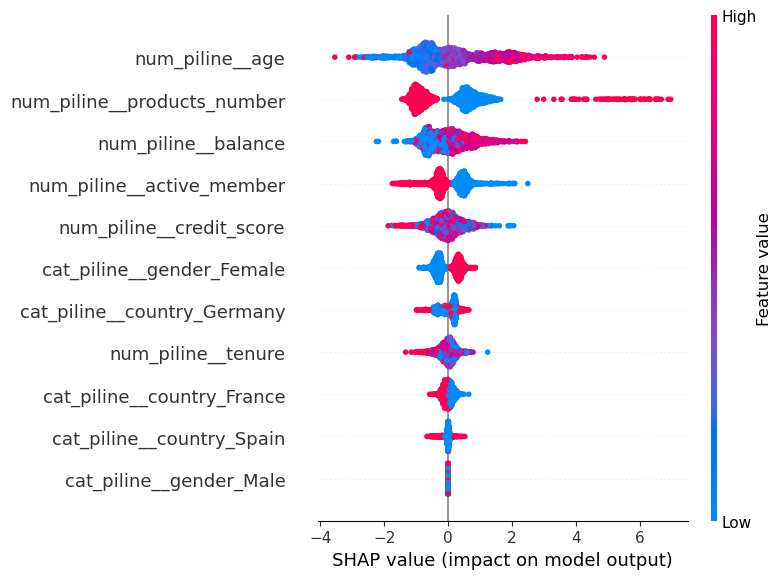

In [250]:
model_XGB.fit(X_train, y_train)

preproc = model_XGB.named_steps['preporc']
XGB_model = model_XGB.named_steps['m_XGB']

X_train_t = preproc.transform(X_train)
X_test_t = preproc.transform(X_test)

feature_names = preproc.get_feature_names_out()

explainer = shap.TreeExplainer(XGB_model, X_train_t)

shap_values = explainer(X_test_t)

plt.figure()
shap.summary_plot(shap_values, X_test_t, feature_names=feature_names)
plt.show()